# Issue #1 — Chart 2: BNPL usage and late payment by income, 2024

**Question:** among BNPL users, who's most likely to get in trouble with it and how does that map to income?

**Ending sentence this chart supports:** "Fast fashion narrowed the price gap, but not the burden gap."

**Data source:** Federal Reserve SHED (Survey of Household Economics and Decisionmaking)
- 2024 report, Table 34: BNPL use by demographic characteristics (usage + late payment by income)
- Aggregated into `data/raw/issue-01/shed_bnpl_by_income.csv`

**Method:** Two-panel bar chart. Left panel shows BNPL usage rate by income bracket. Right panel shows late-payment rate among BNPL users, by income bracket. Both use 2024 SHED data. The lowest income bracket is highlighted in Dusty across both panels to signal "here's the issue."

**Honest caveat we'll disclose:** the usage panel doesn't monotonically decrease with income — the $25-49k bracket is actually the highest at 19%. The story isn't "lower income = more usage," it's "lower income = more *harm* from usage." The right panel is where the burden gap becomes undeniable.

## 1. Setup

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# This notebook lives at data-worn-thin/notebooks/issue-01/
# So we need .parent.parent to climb up to the repo root.
REPO_ROOT = Path.cwd().parent.parent

# Everything is scoped to issue-01 subfolders to keep issues cleanly separated.
RAW_DIR = REPO_ROOT / "data" / "raw" / "issue-01"
PROCESSED_DIR = REPO_ROOT / "data" / "processed" / "issue-01"
POST_EXPORTS = REPO_ROOT / "content" / "posts" / "issue-01-buy-now-owe-later" / "exports"
PALETTE_FILE = REPO_ROOT / "brand" / "palette.json"

# Safety check: verify we're pointing at the actual repo
assert (REPO_ROOT / "brand").exists() and (REPO_ROOT / "data").exists(), (
    f"REPO_ROOT looks wrong: {REPO_ROOT}\n"
    f"Expected to find brand/ and data/ folders inside it."
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
POST_EXPORTS.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Raw data expected in: {RAW_DIR}")
print(f"Processed output goes to: {PROCESSED_DIR}")
print(f"Chart exports go to: {POST_EXPORTS}")

Repo root: c:\Users\juvin\OneDrive\Desktop\data-worn-thin
Raw data expected in: c:\Users\juvin\OneDrive\Desktop\data-worn-thin\data\raw\issue-01
Processed output goes to: c:\Users\juvin\OneDrive\Desktop\data-worn-thin\data\processed\issue-01
Chart exports go to: c:\Users\juvin\OneDrive\Desktop\data-worn-thin\content\posts\issue-01-buy-now-owe-later\exports


## 2. Load brand palette

In [3]:
def load_palette():
    fallback = {
        "cocoa": "#664E44",
        "dusty": "#B08B7F",
        "peach": "#FFE8D6",
        "cream": "#FAF4E5",
        "sage": "#C7C3B0",
    }
    if not PALETTE_FILE.exists():
        return fallback
    try:
        with PALETTE_FILE.open() as f:
            data = json.load(f)
        if isinstance(data, dict) and "palette" in data:
            return {item["name"].lower(): item["hex"] for item in data["palette"]}
        if isinstance(data, dict):
            return {k.lower(): v for k, v in data.items()}
        return {item["name"].lower(): item["hex"] for item in data}
    except (json.JSONDecodeError, KeyError, TypeError):
        return fallback

PALETTE = load_palette()
PALETTE

{'cocoa': '#664E44',
 'dusty': '#B08B7F',
 'peach': '#FFE8D6',
 'cream': '#FAF4E5',
 'sage': '#C7C3B0'}

## 3. Load the SHED BNPL data

The CSV holds both 2021 and 2024 numbers, so we filter to 2024 and just the four income brackets we want to chart. The other rows (aggregate, "under $50k combined", reasons figures) stay in the file as documentation for the caption's temporal claims.

In [6]:
SHED_FILE = RAW_DIR / "shed_bnpl_by_income.csv"

if not SHED_FILE.exists():
    print(f"Missing file: {SHED_FILE}")
    print("Save the transcribed SHED data there before continuing.")

shed = pd.read_csv(SHED_FILE)
print(f"Total rows loaded: {len(shed)}")
print()
print(shed)

Total rows loaded: 13

    year            income_bracket  pct_used_bnpl  pct_paid_late  \
0   2021          Less than $25000           12.0           23.0   
1   2021            25000 to 49999           14.0           18.0   
2   2021            50000 to 99999           11.0           11.0   
3   2021            100000 or more            7.0            6.0   
4   2021                 Aggregate           10.0           15.0   
5   2021     Under $50000 combined            NaN            NaN   
6   2021  100000 or more (reasons)            NaN            NaN   
7   2024          Less than $25000           16.0           40.0   
8   2024            25000 to 49999           19.0           26.0   
9   2024            50000 to 99999           16.0           21.0   
10  2024            100000 or more           11.0           13.0   
11  2024                 Aggregate           15.0           24.0   
12  2024     Under $50000 combined            NaN            NaN   

    pct_only_way_afford 

## 4. Filter to the four income brackets for 2024

Keep only the rows that will actually appear on the chart. Aggregate rows and the reasons-related rows are left in the CSV as documentation but excluded from the chart data.

In [7]:
BRACKETS_TO_CHART = [
    "Less than $25000",
    "25000 to 49999",
    "50000 to 99999",
    "100000 or more",
]

chart_df = shed[
    (shed["year"] == 2024)
    & (shed["income_bracket"].isin(BRACKETS_TO_CHART))
].copy()

# Preserve the intended low-to-high order (pandas doesn't guarantee CSV order)
chart_df["income_bracket"] = pd.Categorical(
    chart_df["income_bracket"],
    categories=BRACKETS_TO_CHART,
    ordered=True,
)
chart_df = chart_df.sort_values("income_bracket").reset_index(drop=True)

# Cleaner display labels for the x-axis
LABEL_MAP = {
    "Less than $25000": "< $25k",
    "25000 to 49999": "$25-49k",
    "50000 to 99999": "$50-99k",
    "100000 or more": "$100k+",
}
chart_df["label"] = chart_df["income_bracket"].map(LABEL_MAP)

print(chart_df[["label", "pct_used_bnpl", "pct_paid_late"]])

     label  pct_used_bnpl  pct_paid_late
0   < $25k           16.0           40.0
1  $25-49k           19.0           26.0
2  $50-99k           16.0           21.0
3   $100k+           11.0           13.0


### Sanity check the numbers

Before plotting, compute the key comparisons we'll cite in the caption to make sure they match what we expect:

- Late payment rate: lowest vs. highest income bracket
- Usage rate: lowest vs. highest income bracket
- The "late payment multiplier" — how many times more often the lowest bracket pays late vs the highest

In [8]:
low = chart_df.iloc[0]
high = chart_df.iloc[-1]

print(f"Lowest bracket ({low['label']}):")
print(f"  Used BNPL:       {low['pct_used_bnpl']:.0f}%")
print(f"  Paid late:       {low['pct_paid_late']:.0f}%")
print()
print(f"Highest bracket ({high['label']}):")
print(f"  Used BNPL:       {high['pct_used_bnpl']:.0f}%")
print(f"  Paid late:       {high['pct_paid_late']:.0f}%")
print()
print(f"Late-payment ratio (lowest / highest): "
      f"{low['pct_paid_late'] / high['pct_paid_late']:.2f}x")
print(f"Absolute gap in late-payment rate:    "
      f"{low['pct_paid_late'] - high['pct_paid_late']:.0f} percentage points")

Lowest bracket (< $25k):
  Used BNPL:       16%
  Paid late:       40%

Highest bracket ($100k+):
  Used BNPL:       11%
  Paid late:       13%

Late-payment ratio (lowest / highest): 3.08x
Absolute gap in late-payment rate:    27 percentage points


## 5. Build the two-panel chart

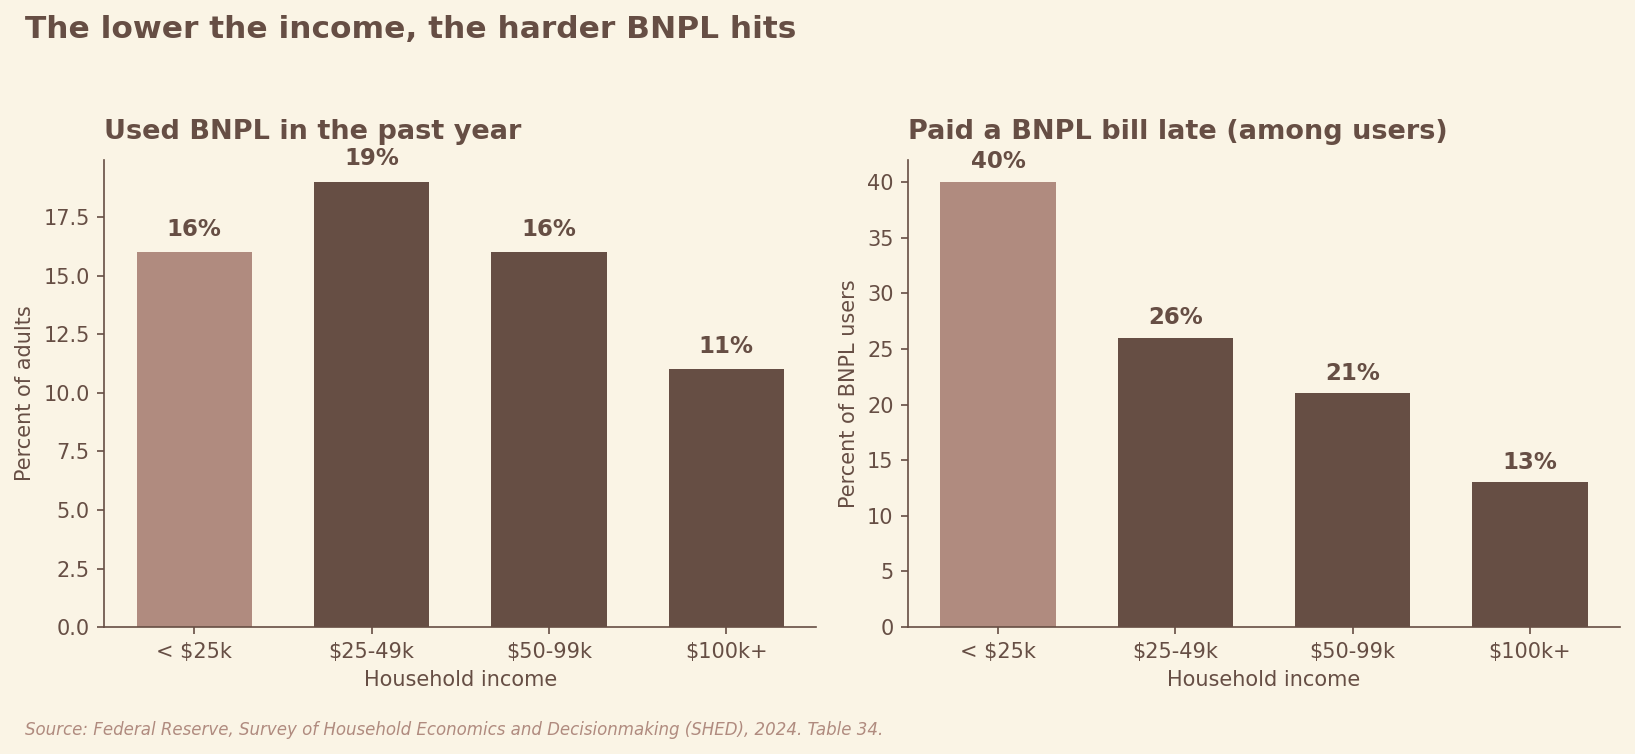

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), dpi=150, sharey=False)
fig.patch.set_facecolor(PALETTE["cream"])
for ax in (ax1, ax2):
    ax.set_facecolor(PALETTE["cream"])

# Bar colors: lowest bracket in Dusty ("flag the issue"), rest in Cocoa
bar_colors = [
    PALETTE["dusty"] if lbl == "< $25k" else PALETTE["cocoa"]
    for lbl in chart_df["label"]
]

# ---- Left panel: BNPL usage by income ----
bars1 = ax1.bar(chart_df["label"], chart_df["pct_used_bnpl"],
                color=bar_colors, width=0.65)
for bar, pct in zip(bars1, chart_df["pct_used_bnpl"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{pct:.0f}%",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold", color=PALETTE["cocoa"],
    )
ax1.set_title("Used BNPL in the past year", color=PALETTE["cocoa"],
              loc="left", pad=10, fontsize=13, fontweight="bold")
ax1.set_ylabel("Percent of adults", color=PALETTE["cocoa"])

# ---- Right panel: late payment among BNPL users ----
bars2 = ax2.bar(chart_df["label"], chart_df["pct_paid_late"],
                color=bar_colors, width=0.65)
for bar, pct in zip(bars2, chart_df["pct_paid_late"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{pct:.0f}%",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold", color=PALETTE["cocoa"],
    )
ax2.set_title("Paid a BNPL bill late (among users)", color=PALETTE["cocoa"],
              loc="left", pad=10, fontsize=13, fontweight="bold")
ax2.set_ylabel("Percent of BNPL users", color=PALETTE["cocoa"])

# Common styling for both axes
for ax in (ax1, ax2):
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(PALETTE["cocoa"])
    ax.tick_params(colors=PALETTE["cocoa"])
    ax.set_xlabel("Household income", color=PALETTE["cocoa"])

# Overall title
fig.suptitle(
    "The lower the income, the harder BNPL hits",
    color=PALETTE["cocoa"], fontsize=15, fontweight="bold",
    x=0.02, y=0.98, ha="left",
)

# Source citation
fig.text(
    0.02, 0.02,
    "Source: Federal Reserve, Survey of Household Economics and Decisionmaking (SHED), 2024. Table 34.",
    fontsize=8, color=PALETTE["dusty"], style="italic",
)

plt.tight_layout(rect=[0, 0.05, 1, 0.94])
plt.show()

## 6. Findings

BNPL usage is roughly spread across income groups:
- the second-lowest bracket ($25-49k) actually has the highest usage at 19%
- the four bar heights in the left panel are all clustered between 11% and 19%.  
-> This doesn't fit the neat "poor people use BNPL more" narrative.  

But late payment tells a completely different story. Among users, 40% of the lowest-income bracket paid late, over 3x the rate of the highest-income bracket (13%). The right panel shows a clean gradient: every step down in income means a bigger chance of getting hit with a late fee or hurting your credit.

Between 2021 and 2024, both gaps widened. The late-payment gap between lowest and highest income brackets doubled from 17 points in 2021 (23% vs 6%) to 27 points in 2024 (40% vs 13%); and the share of low-income users saying BNPL was "the only way I could afford it" climbed from around 60% to 72%.

Key numbers
- BNPL usage rate by income (2024): 16% / 19% / 16% / 11% from lowest to highest bracket
- Late payment rate among users (2024): 40% / 26% / 21% / 13% from lowest to highest bracket
- Late payment ratio (lowest vs highest income): 3.08x
- Absolute late payment gap: 27 percentage points
- Low-income BNPL users saying it was "the only way I could afford it" (2024): 72%, up from ~60% in 2021

## 7. Save outputs

In [10]:
out_csv = PROCESSED_DIR / "bnpl_by_income_2024.csv"
chart_df[["label", "income_bracket", "pct_used_bnpl", "pct_paid_late"]].to_csv(out_csv, index=False)
print(f"Processed data saved to: {out_csv}")

out_png = POST_EXPORTS / "chart2_bnpl_by_income.png"
fig.savefig(out_png, facecolor=fig.get_facecolor(), bbox_inches="tight")
print(f"Chart saved to: {out_png}")

Processed data saved to: c:\Users\juvin\OneDrive\Desktop\data-worn-thin\data\processed\issue-01\bnpl_by_income_2024.csv
Chart saved to: c:\Users\juvin\OneDrive\Desktop\data-worn-thin\content\posts\issue-01-buy-now-owe-later\exports\chart2_bnpl_by_income.png


##8. Sources cited in the analysis

In [11]:
# Auto-generated from data/raw/issue-01/source-files/sources.csv
# so the notebook and any downstream captions cite exactly the same set.

SOURCES_FILE = REPO_ROOT / "data" / "raw" / "issue-01" / "source-files" / "sources.csv"

def format_apa(row):
    author = row["author_org"]
    year = row["year"]
    title = row["title"]
    url = row["url"]
    if row["type"] in ("dataset", "report"):
        return f"{author}. ({year}). *{title}*. {url}"
    return f"{author}. ({year}). {title}. {url}"

if SOURCES_FILE.exists():
    sources = pd.read_csv(SOURCES_FILE)
    THIS_CHART = "Chart 2"
    used_here = sources[sources["used_for"].str.contains(THIS_CHART, case=False, na=False)]

    print(f"Sources cited in {THIS_CHART}:")
    print("=" * 70)
    for _, row in used_here.iterrows():
        print(f"\n[{row['source_id']}] {format_apa(row)}")
        if pd.notna(row.get("notes")) and row["notes"]:
            print(f"    Notes: {row['notes']}")

    print()
    print("=" * 70)
    print(f"Full sources.csv: {SOURCES_FILE}")
    print(f"Total sources tracked: {len(sources)}, cited in {THIS_CHART}: {len(used_here)}")
else:
    print(f"Sources file not found at {SOURCES_FILE}")
    print("Create it before running this cell.")

Sources cited in Chart 2:

[SHED-2021] Federal Reserve Board. (2022). *Report on the Economic Well-Being of U.S. Households in 2021 - Banking and Credit*. https://www.federalreserve.gov/publications/2022-economic-well-being-of-us-households-in-2021-banking-and-credit.htm
    Notes: Table 14 (usage and late payment by income) + Figure 28 (reasons aggregate) + narrative for reasons by income

[SHED-2024] Federal Reserve Board. (2025). *Report on the Economic Well-Being of U.S. Households in 2024 - Banking and Credit*. https://www.federalreserve.gov/publications/2025-economic-well-being-of-us-households-in-2024-banking-and-credit.htm
    Notes: Table 34 (usage and late payment by income) + Table 33 (reasons aggregate) + narrative for reasons by income

Full sources.csv: c:\Users\juvin\OneDrive\Desktop\data-worn-thin\data\raw\issue-01\source-files\sources.csv
Total sources tracked: 6, cited in Chart 2: 2
